# Customer KPI & Segmentation EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


## Notebook Roadmap

1. Data Setup & KPI Baseline
2. Bivariate Behavior Comparison
3. Time-slot Pattern (Day x Hour)
4. Customer Segmentation (User-level)
5. Segment Preferences (Product / Aisle)
6. Retention & Churn
7. Basket Value by Category
8. CLV Trends & Segment CLV
9. Extra Diagnostics (Funnel / Gateway / Trend / Histogram)
10. Executive Summary

Run guide:
- ตั้งค่า `USE_SAMPLE` ที่ cell โหลดข้อมูล
- รันจากบนลงล่างเพื่อให้ตัวแปรกลาง (เช่น `rfm`, `segment_txn`, `customer_monthly`) พร้อมใช้งานครบ

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,aisle_id,department_id,aisle,department,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Soda,77,7,soft drinks,beverages,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Original Beef Jerky,23,19,popcorn jerky,snacks,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0,0.0,2015-07-01,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0,0.0,2015-07-01,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household,1,0


# 1) Customer Segmentation Value Analysis

แบ่งลูกค้าออกเป็นกลุ่มตามพฤติกรรม แล้วประมาณ **มูลค่าสัมพัทธ์** ของแต่ละกลุ่มผ่าน Value Index

| ขั้นตอน | รายละเอียด |
|---------|-----------|
| 1.1 | สร้าง User Segment (Whales / Regulars / Churned) |
| 1.2 | กำหนด Value Weight ตาม Aisle → คำนวณ Value Index |
| 1.3 | Spending Intensity & Segment Strategy Map |

### 1.1) User Segmentaion

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

Segment summary:


,segment,users,median_total_orders,median_avg_basket_size,median_reorder_ratio,median_days_since_last_order
0,Whales,20644,51.0,9.315789,0.725983,1.0
1,Regulars,185565,8.0,8.863636,0.400000,1.0
2,Churned,0,NaN,NaN,NaN,NaN


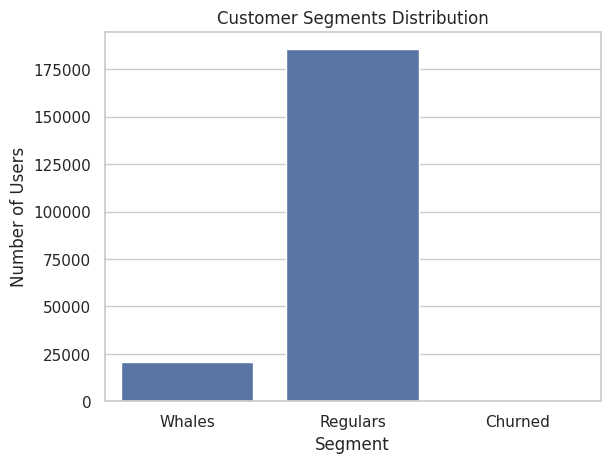

In [2]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_avg_basket_size=("avg_basket_size", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)

print("Segment summary:")
show_df(segment_summary)

sns.countplot(data=rfm, x="segment", order=segment_summary["segment"])
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.show()

### 💡 Segment Insights

#### 🐋 Whales — High-Value Power Users
> - ลูกค้ากลุ่มนี้มี **loyalty สูงมาก** (reorder ~73%)
> - สั่งซื้อบ่อย (51 orders median) และยัง active ล่าสุด
> - เป็นกลุ่มที่สร้างรายได้หลัก → **ควรรักษาไว้ด้วย loyalty program**

#### 👥 Regulars — Core Mainstream Users
> - เป็นฐานลูกค้าหลัก (~90%) แต่ **reorder ratio ยังต่ำ** (~40%)
> - พฤติกรรมอยู่ระหว่าง ทดลองสินค้าและซื้อซ้ำ
> - มี potential สูงในการ convert ไปเป็น Whales → **ใช้ personalized recommendation**

#### 🔴 Churned — Inactive Users
> - ไม่ได้สั่งซื้อมานานกว่า 30 วัน
> - ควรทำ **win-back campaign** ด้วย incentive หรือ reminder notification

---

### 1.2) Segment Value Contribution

เนื่องจากไม่มีข้อมูลราคาจริง เราจึงสร้าง **Value Index** จาก Aisle-level weight เพื่อประมาณมูลค่าสัมพัทธ์ของแต่ละ order line

**ขั้นตอน:**
1. สำรวจ Aisles ที่มีอยู่ในข้อมูล
2. กำหนด weight สำหรับแต่ละ aisle (ตามช่วงราคาตลาดทั่วไป)
3. คำนวณ `value_index = quantity × value_weight` ต่อ order line

In [3]:
aisles = (
    pd.Series(df["aisle"].dropna().unique(), name="aisle")
    .sort_values()
    .reset_index(drop=True)
)

aisle_counts = (
    df["aisle"]
    .value_counts(dropna=False)
    .rename_axis("aisle")
    .reset_index(name="order_lines")
)

print(f"Unique aisles: {len(aisles):,}")
show_df(aisle_counts, title="Aisle frequency (order lines):", n=len(aisle_counts))

Unique aisles: 134
Aisle frequency (order lines):


,aisle,order_lines
0,fresh fruits,3642188
1,fresh vegetables,3418021
2,packaged vegetables fruits,1765313
3,yogurt,1452343
4,packaged cheese,979763
5,milk,891015
6,water seltzer sparkling water,841533
7,chips pretzels,722470
8,soy lactosefree,638253
9,bread,584834


#### 📌 Value Weight Map

> **Assumption:** ไม่มีข้อมูลราคาจริง — ใช้ relative weight ตาม aisle category เพื่อประมาณ spending intensity
> Weight สูง = หมวดสินค้าราคาสูง (เช่น alcohol ≈ 3.0×, fresh produce ≈ 1.0×)

| กลุ่ม | ตัวอย่าง Aisle | Weight |
|------|--------------|--------|
| 🟢 Fresh / Low | fresh fruits, vegetables | 1.0× |
| 🟡 Dairy / Bakery | milk, yogurt, bread | 1.4–1.7× |
| 🔴 Meat / Seafood | meat counter, seafood | 2.3–2.7× |
| 🟣 Alcohol / Personal care | wines, spirits, skin care | 2.4–3.8× |

In [4]:
# Category-level value weight (relative, not actual price)
value_weight_map = {
    # 🟢 Fresh / Low value
    "fresh fruits": 1.0,
    "fresh vegetables": 1.0,
    "packaged vegetables fruits": 1.2,
    "fresh herbs": 1.3,
    "water seltzer sparkling water": 1.1,

    # 🟡 Dairy / Basic food
    "milk": 1.4,
    "yogurt": 1.5,
    "eggs": 1.5,
    "cream": 1.6,
    "butter": 1.6,
    "packaged cheese": 1.7,
    "other creams cheeses": 1.8,

    # 🟡 Bakery / carbs
    "bread": 1.4,
    "buns rolls": 1.4,
    "breakfast bakery": 1.5,
    "tortillas flat bread": 1.5,
    "dry pasta": 1.3,
    "grains rice dried goods": 1.3,

    # 🟡 Snacks / packaged
    "chips pretzels": 1.6,
    "crackers": 1.5,
    "cookies cakes": 1.7,
    "candy chocolate": 1.6,
    "popcorn jerky": 1.7,
    "trail mix snack mix": 1.8,
    "nuts seeds dried fruit": 1.8,

    # 🟡 Drinks
    "soft drinks": 1.4,
    "juice nectars": 1.5,
    "tea": 1.4,
    "coffee": 1.6,
    "energy sports drinks": 1.7,

    # 🔴 Protein / meat
    "meat counter": 2.5,
    "poultry counter": 2.4,
    "seafood counter": 2.7,
    "packaged meat": 2.3,
    "packaged poultry": 2.2,
    "packaged seafood": 2.4,
    "hot dogs bacon sausage": 2.2,
    "lunch meat": 2.0,

    # 🔴 Frozen / prepared
    "frozen meals": 2.0,
    "frozen produce": 1.6,
    "frozen pizza": 2.1,
    "frozen appetizers sides": 2.0,
    "frozen breakfast": 1.8,
    "prepared meals": 2.2,
    "prepared soups salads": 2.0,

    # 🔴 Pantry / cooking
    "canned meals beans": 1.6,
    "canned jarred vegetables": 1.4,
    "canned fruit applesauce": 1.4,
    "pasta sauce": 1.5,
    "condiments": 1.5,
    "spices seasonings": 1.6,
    "oils vinegars": 1.8,
    "baking ingredients": 1.5,
    "doughs gelatins bake mixes": 1.5,

    # 🔴 Special food
    "baby food formula": 2.5,
    "tofu meat alternatives": 2.2,
    "protein meal replacements": 2.6,
    "international": 1.7,
    "asian foods": 1.7,
    "latino foods": 1.6,
    "indian foods": 1.7,

    # 🟣 Premium / alcohol
    "beers coolers": 3.0,
    "red wines": 3.2,
    "white wines": 3.2,
    "spirits": 3.5,
    "specialty wines champagnes": 3.8,

    # 🟣 Non-food high value
    "cleaning products": 2.3,
    "laundry": 2.4,
    "dish detergents": 2.2,
    "paper goods": 2.0,
    "trash bags liners": 2.1,
    "air fresheners candles": 2.2,

    # 🟣 Personal care
    "personal care": 2.5,
    "oral hygiene": 2.3,
    "body lotions soap": 2.4,
    "hair care": 2.4,
    "skin care": 2.6,
    "facial care": 2.6,
    "deodorants": 2.2,
    "feminine care": 2.4,

    # 🟣 Baby / pets
    "diapers wipes": 2.8,
    "baby bath body care": 2.6,
    "baby accessories": 2.7,
    "cat food care": 2.4,
    "dog food care": 2.4,

    # fallback
    "missing": 1.5,
    "other": 1.5
}

# 2) CREATE VALUE INDEX
# =========================
df["value_weight"] = df["aisle"].map(value_weight_map)
df["value_weight"] = df["value_weight"].fillna(1.5)

df["quantity"] = 1
df["value_index"] = df["quantity"] * df["value_weight"]


In [5]:
# =========================
# 3) CUSTOMER LEVEL AGG
# =========================
customer_df = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_items=("product_id", "count"),
        total_value_index=("value_index", "sum"),
    )
    .reset_index()
)

customer_df["avg_value_per_order"] = (
    customer_df["total_value_index"] / customer_df["total_orders"]
)

customer_df["avg_items_per_order"] = (
    customer_df["total_items"] / customer_df["total_orders"]
)

# =========================
# 4) MERGE WITH RFM SEGMENT
# =========================
customer_df = customer_df.merge(
    rfm[["user_id", "segment"]],
    on="user_id",
    how="left"
)

# =========================
# 5) SEGMENT KPI
# =========================
segment_kpi = (
    customer_df.groupby("segment")
    .agg(
        total_users=("user_id", "count"),
        total_value=("total_value_index", "sum"),
        avg_value_per_user=("total_value_index", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_items_per_order=("avg_items_per_order", "mean"),
    )
    .reset_index()
)

# optional: sort by value
segment_kpi = segment_kpi.sort_values(
    by="total_value", ascending=False
)

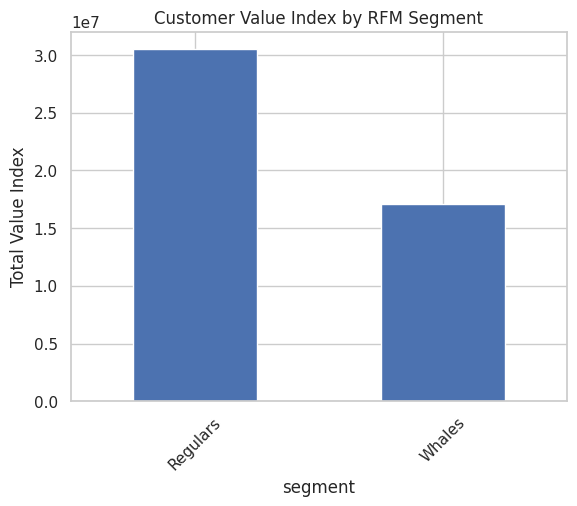

In [6]:
# =========================
# 6) VISUALIZATION
# =========================
plt.figure()
segment_kpi.set_index("segment")["total_value"].plot(kind="bar")
plt.title("Customer Value Index by RFM Segment")
plt.ylabel("Total Value Index")
plt.xticks(rotation=45)
plt.show()

---

### 1.3) Spending Intensity & Segment Strategy Map

วิเคราะห์ **ความเข้มข้นในการใช้จ่าย** ต่อลูกค้าในแต่ละ segment และสร้าง Strategy Map เพื่อเปรียบเทียบ:
- **Volume** (จำนวนลูกค้า) vs **Intensity** (มูลค่าเฉลี่ยต่อคน)
- ช่วยระบุ segment ที่มี ROI สูงสุดสำหรับ marketing investment

In [7]:
segment_kpi = (
    customer_df.groupby("segment")
    .agg(
        total_users=("user_id", "count"),
        total_value=("total_value_index", "sum"),
        avg_value_per_user=("total_value_index", "mean"),
        avg_orders=("total_orders", "mean"),
        avg_items_per_order=("avg_items_per_order", "mean"),
    )
    .reset_index()
)

segment_kpi["value_per_order"] = (
    segment_kpi["total_value"] / 
    (segment_kpi["avg_orders"] * segment_kpi["total_users"])
)

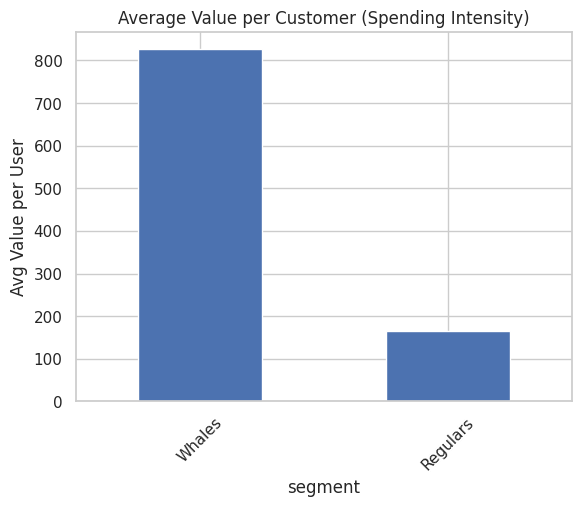

In [8]:
plt.figure()
segment_kpi.set_index("segment")["avg_value_per_user"].plot(kind="bar")
plt.title("Average Value per Customer (Spending Intensity)")
plt.ylabel("Avg Value per User")
plt.xticks(rotation=45)
plt.show()

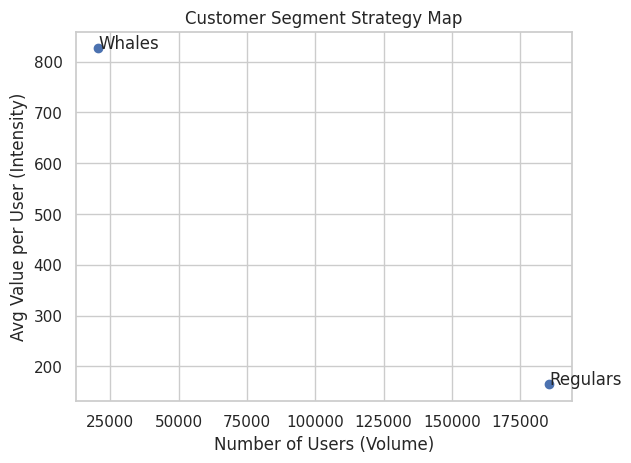

In [9]:
plt.figure()

plt.scatter(
    segment_kpi["total_users"],
    segment_kpi["avg_value_per_user"]
)

# label
for i, txt in enumerate(segment_kpi["segment"]):
    plt.annotate(
        txt,
        (segment_kpi["total_users"][i],
         segment_kpi["avg_value_per_user"][i])
    )

plt.xlabel("Number of Users (Volume)")
plt.ylabel("Avg Value per User (Intensity)")
plt.title("Customer Segment Strategy Map")

plt.show()

### 📊 สรุปเชิง Insight

### 🐋 กลุ่ม Whale
- มีมูลค่าต่อคนสูงมาก (High value per user)
- ซื้อบ่อย / ปริมาณต่อครั้งสูง → คุณภาพเชิง “ความเข้มข้น” ดีมาก
- แต่มี “จำนวนน้อย” → Contribution รวมยังจำกัด

### 👥 กลุ่ม Regular
- มูลค่าต่อคนต่ำกว่า Whale
- แต่มี “จำนวนลูกค้ามาก”
- ทำให้ **รายได้รวม (Total Revenue Contribution)** สูงกว่า

---

### 🔥 Executive Summary
แม้ลูกค้ากลุ่ม Whale จะสร้างมูลค่าต่อคนสูงและมีพฤติกรรมการซื้อที่เข้มข้น  
แต่เนื่องจากมีจำนวนจำกัด ทำให้รายได้รวมยังน้อยกว่ากลุ่ม Regular  
ซึ่งมีจำนวนมากและสามารถสร้างรายได้รวมได้สูงกว่าในภาพรวม

# 2) Customer Segmentation Preference

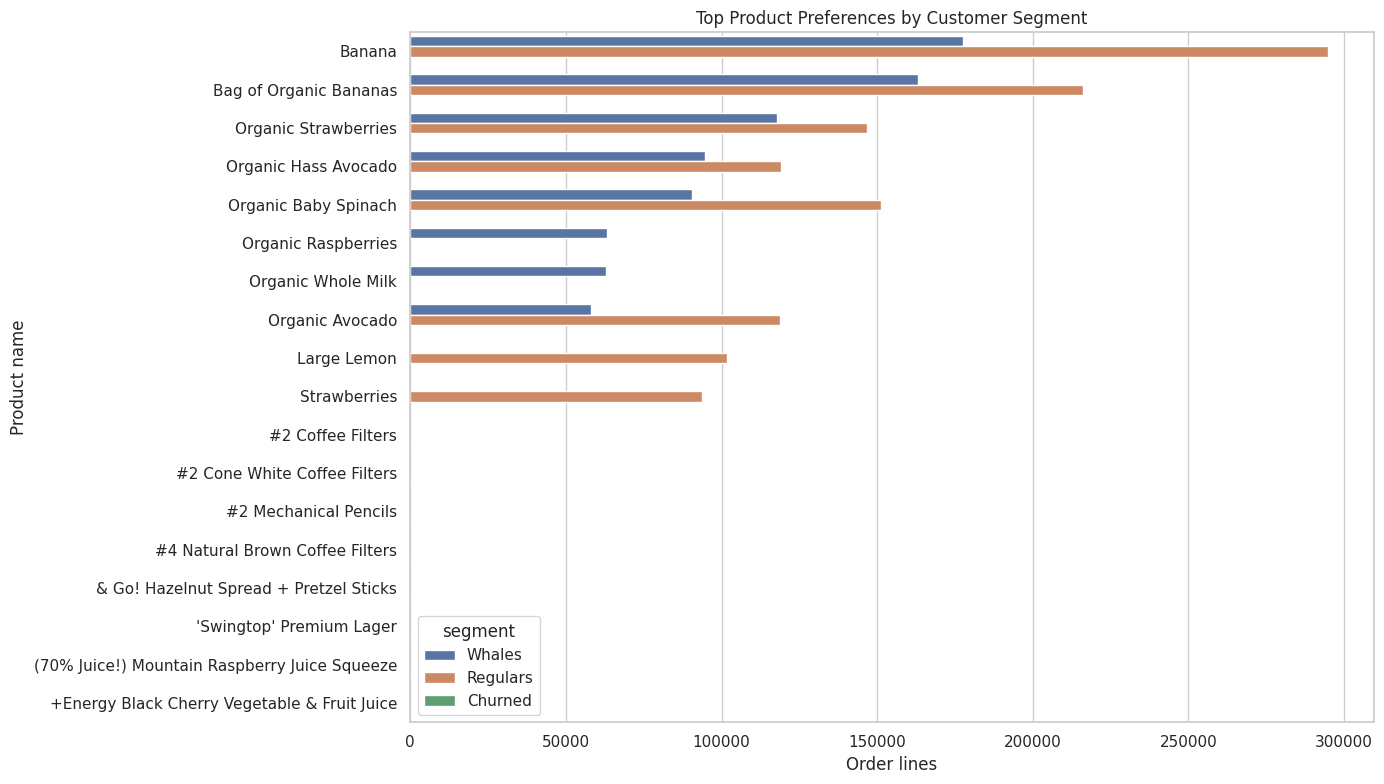

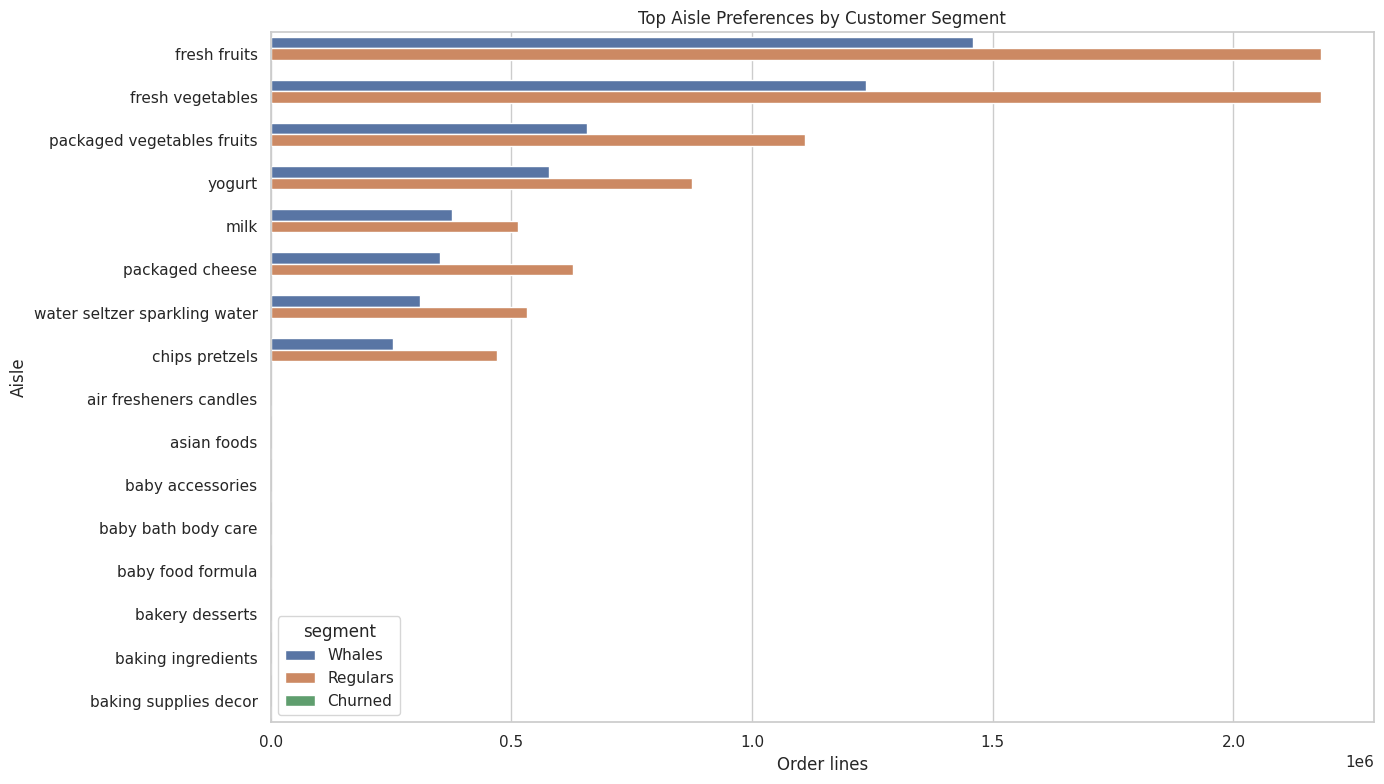

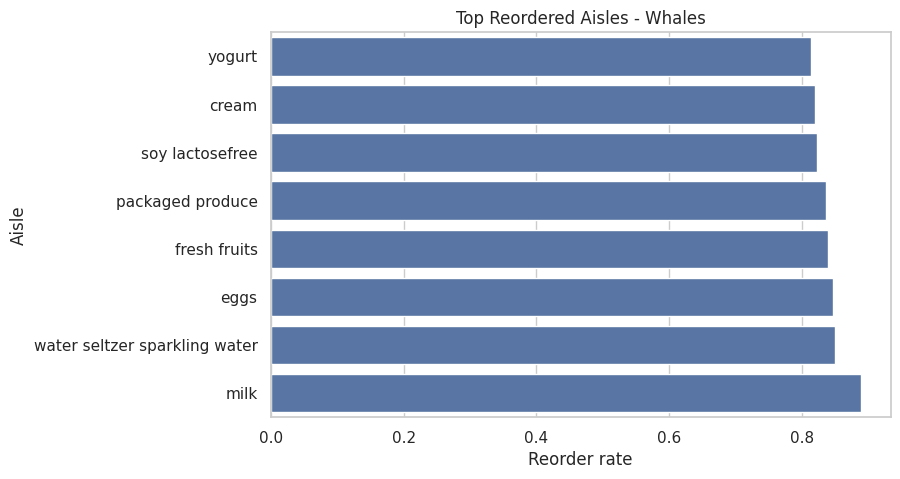

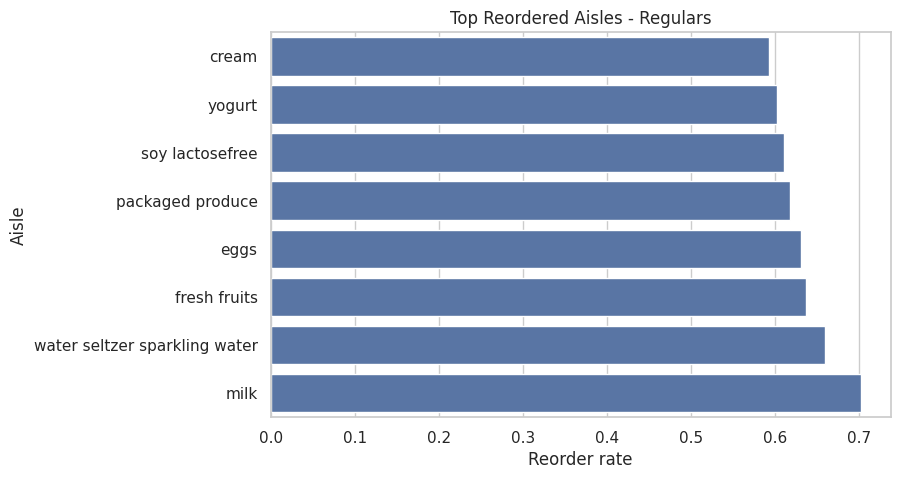

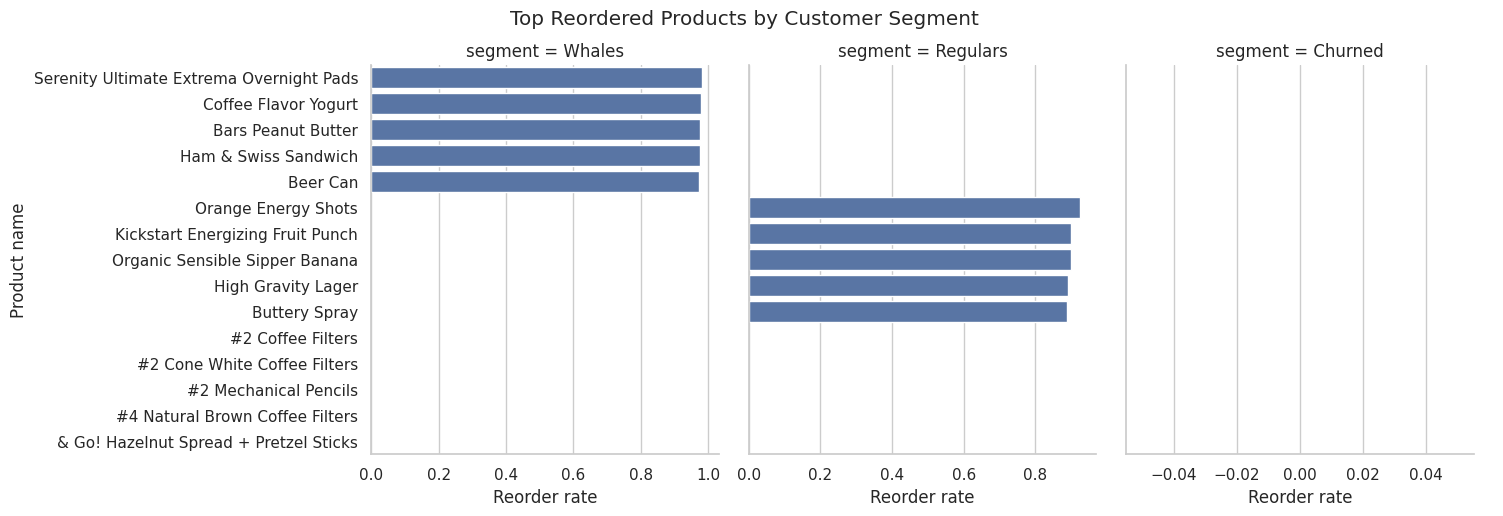

In [10]:
segment_txn = df.copy()

if "segment" not in segment_txn.columns:
    segment_txn = segment_txn.merge(
        rfm[["user_id", "segment"]].drop_duplicates(),
        on="user_id",
        how="left",
    )

segment_txn = segment_txn.dropna(subset=["segment"]).copy()

segment_product_pref = (
    segment_txn.dropna(subset=["product_name"])
    .groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

segment_product_pref["share"] = (
    segment_product_pref["order_lines"]
    / segment_product_pref.groupby("segment", observed=False)["order_lines"].transform("sum")
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.dropna(subset=["product_name"])
    .groupby(["segment", "product_name"], observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_aisle_by_segment = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .query("order_lines >= 50")   # 👈 กัน noise
    .reset_index()
)

top_reordered_aisle_by_segment = (
    top_reordered_aisle_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(8)   # 👈 เอาแค่ top 8
)


top_reordered_by_segment = (
    top_reordered_by_segment.sort_values(
        ["segment", "reorder_rate", "order_lines", "product_name"],
        ascending=[True, False, False, True],
    )
    .groupby("segment", observed=False)
    .head(5)
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()


for seg in top_reordered_aisle_by_segment["segment"].unique():
    temp = top_reordered_aisle_by_segment[
        top_reordered_aisle_by_segment["segment"] == seg
    ].sort_values("reorder_rate", ascending=True)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=temp, x="reorder_rate", y="aisle")
    plt.title(f"Top Reordered Aisles - {seg}")
    plt.xlabel("Reorder rate")
    plt.ylabel("Aisle")
    plt.show()

g = sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1,
    sharex=False,
)
g.set_axis_labels("Reorder rate", "Product name")
g.fig.suptitle("Top Reordered Products by Customer Segment", y=1.03)
plt.show()



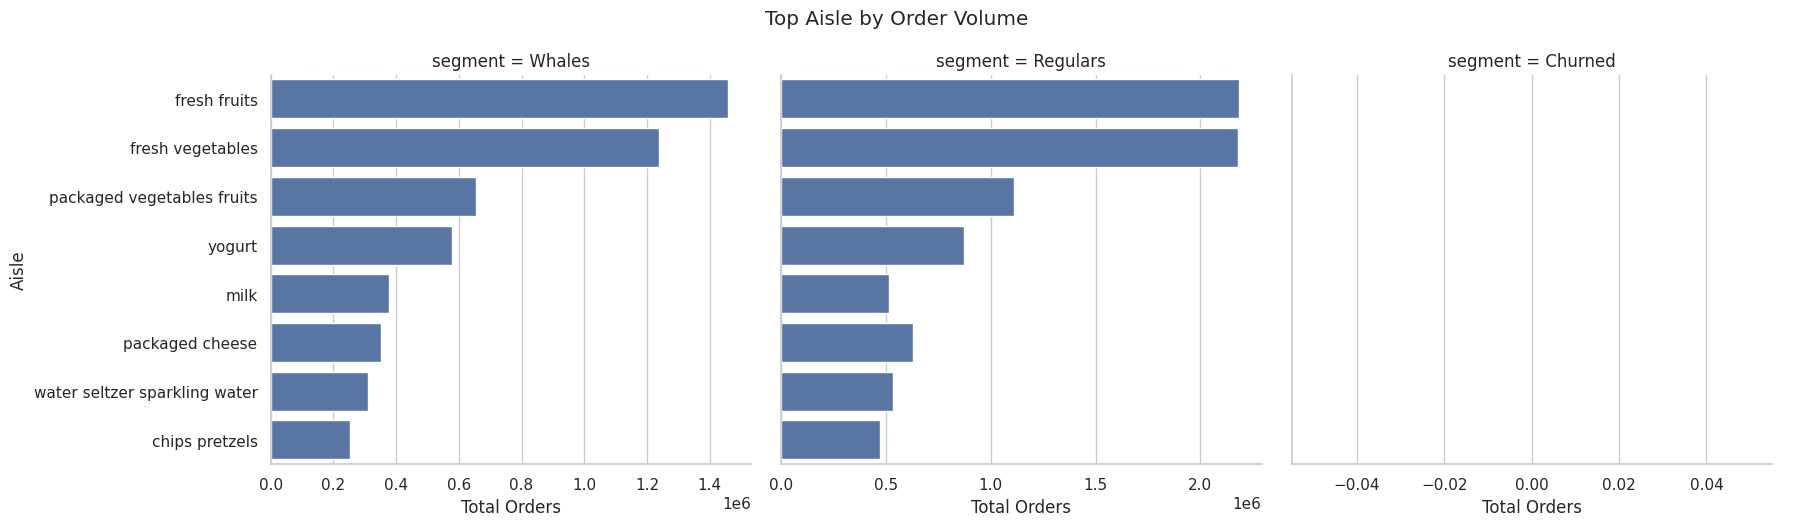

In [11]:
segment_aisle_value = (
    segment_txn
    .groupby(["segment", "aisle"])
    .agg(
        total_orders=("product_id", "count"),
        avg_reorder=("reordered", "mean"),
    )
    .reset_index()
)

top_aisle = (
    segment_aisle_value
    .sort_values(["segment", "total_orders"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(8)
)

g = sns.catplot(
    data=top_aisle,
    x="total_orders",
    y="aisle",
    col="segment",
    kind="bar",
    height=5,
    aspect=1.2,
    sharex=False,
)

g.set_axis_labels("Total Orders", "Aisle")
g.fig.suptitle("Top Aisle by Order Volume", y=1.05)
plt.show()


In [12]:

orders_per_customer = (
    segment_txn
    .groupby(["segment", "user_id"])
    .agg(order_count=("order_id", "nunique"))
    .groupby("segment")
    .agg(
        mean_orders=("order_count", "mean"),
        median_orders=("order_count", "median"),
    )
    .reset_index()
)


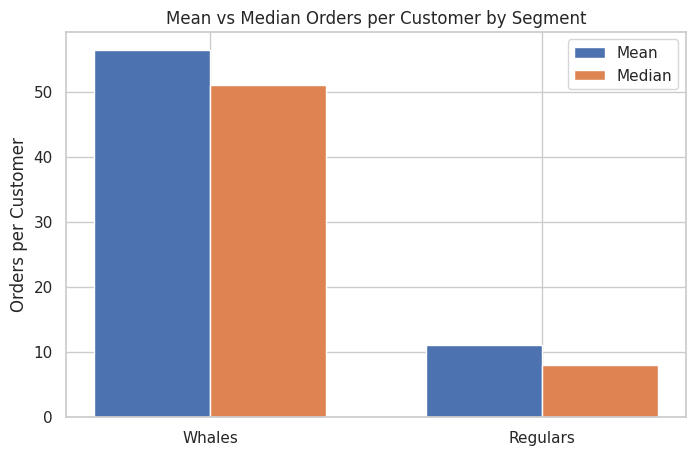

In [13]:
df = orders_per_customer.copy()

x = np.arange(len(df["segment"]))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, df["mean_orders"], width, label="Mean")
plt.bar(x + width/2, df["median_orders"], width, label="Median")

plt.xticks(x, df["segment"])
plt.ylabel("Orders per Customer")
plt.title("Mean vs Median Orders per Customer by Segment")
plt.legend()

plt.show()

แม้ว่ากลุ่มลูกค้า Whale จะมีจำนวนลูกค้าน้อยกว่ากลุ่ม Regular อย่างมีนัยสำคัญ
แต่จากการวิเคราะห์พบว่า Total Orders ของ Whale อยู่ในระดับใกล้เคียงกับกลุ่ม Regular

ซึ่งสะท้อนให้เห็นว่า Whale มีพฤติกรรมการสั่งซื้อสินค้าต่อคน (orders per customer) สูงกว่าอย่างชัดเจน

กล่าวคือ Whale เป็นกลุ่มลูกค้าที่มีมูลค่าสูง (high-value customers) และมีบทบาทสำคัญต่อรายได้ของธุรกิจ

# 3) Customer Segmentation Daily Time Behavior

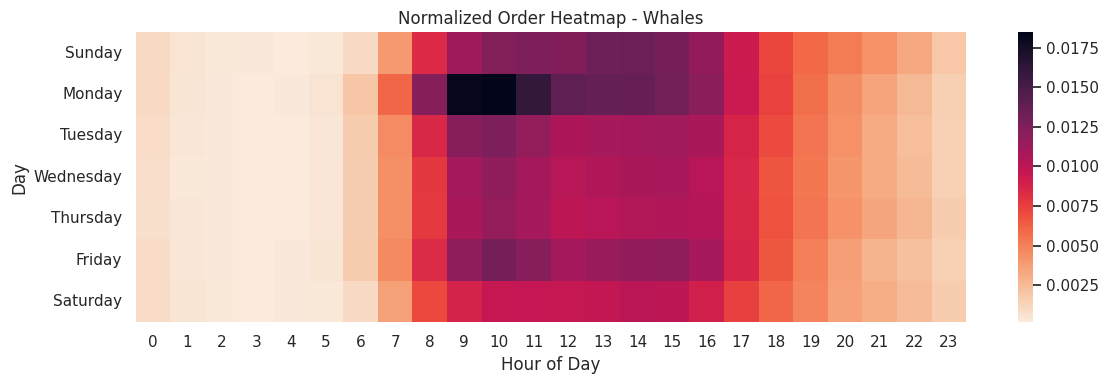

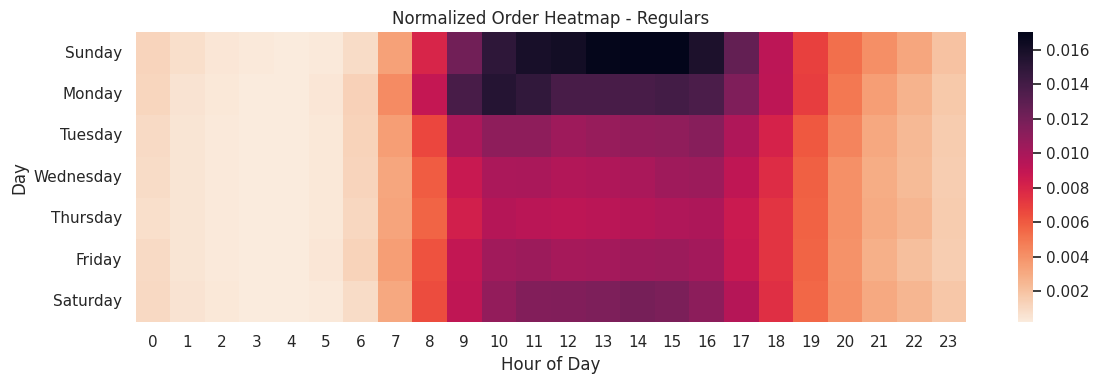

/home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


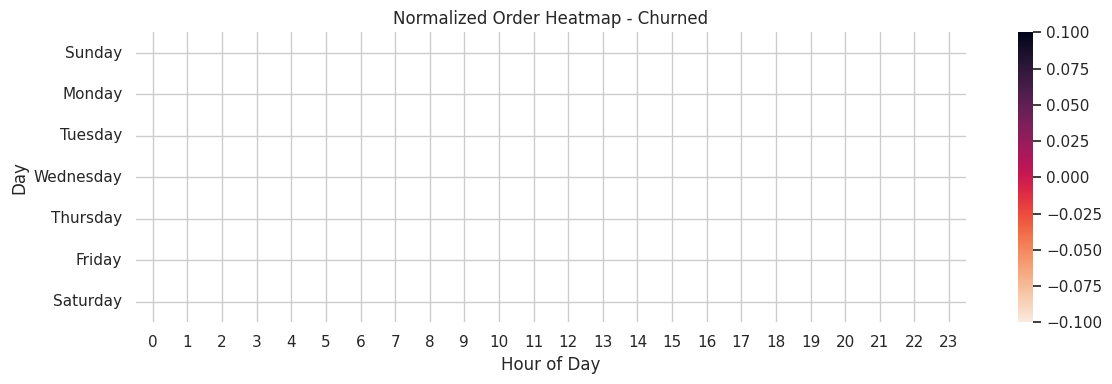

In [14]:
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
day_map = dict(enumerate(day_order))

segment_heatmap = (
    segment_txn[["segment", "order_id", "order_dow", "order_hour_of_day"]]
    .drop_duplicates()
    .assign(day_name=lambda d: d["order_dow"].map(day_map))
    .groupby(["segment", "day_name", "order_hour_of_day"], observed=False)
    .agg(order_count=("order_id", "nunique"))
    .reset_index()
)

for seg in segment_heatmap["segment"].dropna().unique():
    subset = segment_heatmap[segment_heatmap["segment"] == seg]

    pivot = (
        subset.pivot_table(
            index="day_name",
            columns="order_hour_of_day",
            values="order_count",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(day_order)
        .reindex(columns=range(24), fill_value=0)
    )

    # 🔥 normalize
    pivot = pivot / pivot.values.sum()

    plt.figure(figsize=(12, 4))
    sns.heatmap(pivot, cmap="rocket_r")

    plt.title(f"Normalized Order Heatmap - {seg}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Day")
    plt.tight_layout()
    plt.show()

## Peak Hour Detection

เป้าหมาย

หาให้ได้ว่า: “แต่ละ segment peak ช่วงไหน”

In [15]:
peak_hours = (
    segment_heatmap
    .groupby(["segment", "order_hour_of_day"])
    .agg(total_orders=("order_count", "sum"))
    .reset_index()
)

# normalize ต่อ segment
peak_hours["normalized"] = (
    peak_hours.groupby("segment")["total_orders"]
    .transform(lambda x: x / x.sum())
)

# หา top hour
top_peak = (
    peak_hours
    .sort_values(["segment", "normalized"], ascending=[True, False])
    .groupby("segment")
    .head(3)
)

top_peak

,segment,order_hour_of_day,total_orders,normalized
10,Whales,10,104280,0.089581
9,Whales,9,98124,0.084293
11,Whales,11,97927,0.084124
39,Regulars,15,172468,0.084098
38,Regulars,14,171079,0.083421
35,Regulars,11,170079,0.082933
48,Churned,0,0,NaN
49,Churned,1,0,NaN
50,Churned,2,0,NaN


## Difference Heatmap

เป้าหมาย

ดูว่า “Whale ต่างจาก Regular ตรงไหน”

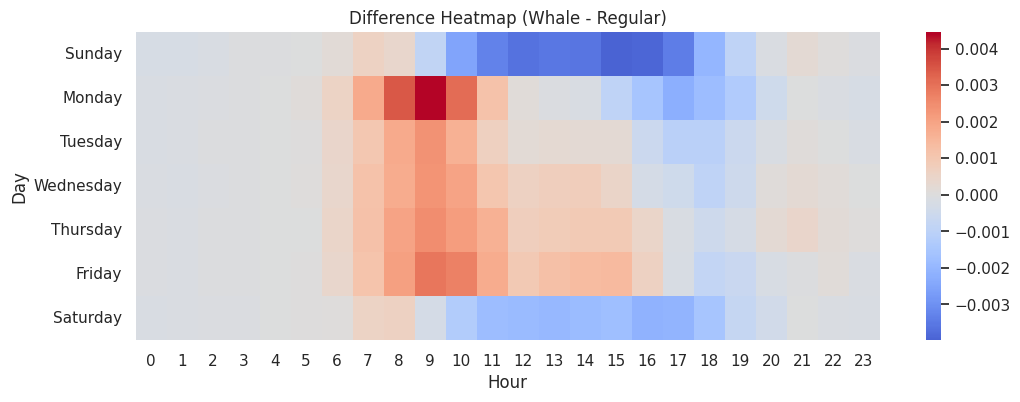

In [16]:
def create_pivot(df, segment):
    subset = df[df["segment"] == segment]

    pivot = (
        subset.pivot_table(
            index="day_name",
            columns="order_hour_of_day",
            values="order_count",
            fill_value=0,
        )
        .reindex(day_order)
        .reindex(columns=range(24), fill_value=0)
    )

    return pivot / pivot.values.sum()  # normalize

whale_pivot = create_pivot(segment_heatmap, "Whales")
regular_pivot = create_pivot(segment_heatmap, "Regulars")

diff = whale_pivot - regular_pivot


#Plotting Visualization
plt.figure(figsize=(12,4))
sns.heatmap(diff, cmap="coolwarm", center=0)

plt.title("Difference Heatmap (Whale - Regular)")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

## Customer Behavior Signature

In [17]:
orders_per_customer_df = (
    orders_per_customer[["segment", "mean_orders", "median_orders"]]
    .rename(columns={"mean_orders": "avg_orders_per_customer"})
)

basket_size = (
    segment_txn.groupby(["segment", "order_id"], observed=False)
    .size()
    .rename("basket_size")
    .reset_index()
    .groupby("segment", observed=False)["basket_size"]
    .mean()
    .reset_index(name="avg_basket_size")
)

reorder_rate = (
    segment_txn.groupby("segment", observed=False)["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
)

peak = (
    top_peak.groupby("segment", observed=False)["order_hour_of_day"]
    .apply(list)
    .reset_index(name="peak_hours")
)

signature = (
    orders_per_customer_df
    .merge(basket_size, on="segment", how="left")
    .merge(reorder_rate, on="segment", how="left")
    .merge(peak, on="segment", how="left")
    .sort_values("avg_orders_per_customer", ascending=False)
)

signature

,segment,avg_orders_per_customer,median_orders,avg_basket_size,reorder_rate,peak_hours
0,Whales,56.388539,51.0,3.652601,0.732740,"[10, 9, 11]"
1,Regulars,11.051594,8.0,6.436282,0.508521,"[15, 14, 11]"
